In [70]:
#Name- Rramandeip Singh
#Student Id- N10010960

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings("ignore")

These libraries help with:

loading dataset

preprocessing

splitting dataset

visualization

In [10]:
mnist = fetch_openml('mnist_784', version=1)

X = mnist.data
y = mnist.target

print(X.shape)
print(y.shape)

(70000, 784)
(70000,)


Dataset Structure

After loading the dataset, we examine its shape to understand its structure.

The dataset contains:
70,000 total images
784 features per image

Each feature represents the intensity of a pixel in the 28×28 image.

In [17]:
#Separate training and test data

X_train_full = X[:60000]
y_train_full = y[:60000]

X_test = X[60000:]
y_test = y[60000:]

print("Training data:", X_train_full.shape)
print("Test data:", X_test.shape)

Training data: (60000, 784)
Test data: (10000, 784)


In [18]:
#Data Cleaning (Check Missing Values)
print("Missing values:", X_train_full.isnull().sum().sum())

Missing values: 0


MNIST dataset contains no missing values, so no rows need to be removed.

In [19]:
#Normalization

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test)

print("Min value:", X_train_scaled.min())
print("Max value:", X_train_scaled.max())

Min value: 0.0
Max value: 1.0


In [21]:
#train validation split

X_train, X_val, y_train, y_val = train_test_split(
    X_train_scaled,
    y_train_full,
    test_size=0.2,
    random_state=0
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)

Training set: (48000, 784)
Validation set: (12000, 784)


Splitting Training and Validation Data

To properly evaluate model performance during development, the training dataset is further divided into:

Training dataset (48,000 images)
    
Validation dataset (12,000 images)

The training dataset is used to train the machine learning models, while the validation dataset is used to tune model hyperparameters and monitor performance during experimentation.

Using a validation dataset helps prevent overfitting and improves model generalisation.

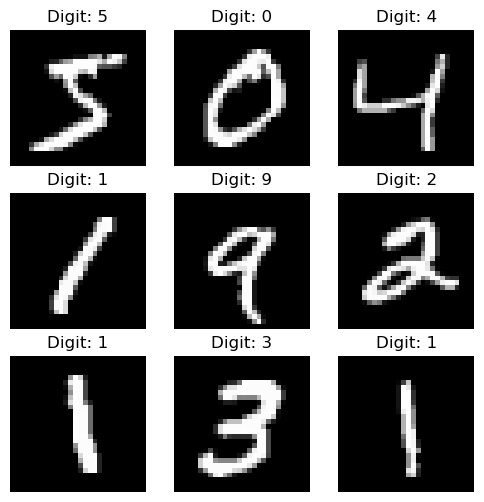

In [42]:
#display sample digit
#Visualize Sample Digits


plt.figure(figsize=(6,6))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train_full.iloc[i].values.reshape(28,28), cmap='gray')
    plt.title("Digit: " + str(y_train_full.iloc[i]))
    plt.axis('off')

plt.show()

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

print("Training Logistic Regression...")

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

pred = log_model.predict(X_test_scaled)

acc = accuracy_score(y_test, pred)

print("Logistic Regression Accuracy:", acc)

Training Logistic Regression...
Logistic Regression Accuracy: 0.9237


Logistic Regression Model

Logistic Regression is a linear classification algorithm commonly used as a baseline model for classification tasks.

Although it is relatively simple, it often performs well on structured datasets.

In this step, the Logistic Regression model is trained using the training dataset and then evaluated on the test dataset to measure its classification accuracy.

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

print("Training Random Forest...")

rf_model = RandomForestClassifier(n_estimators=100)

rf_model.fit(X_train, y_train)

pred = rf_model.predict(X_test_scaled)

acc = accuracy_score(y_test, pred)

print("Random Forest Accuracy:", acc)

Training Random Forest...
Random Forest Accuracy: 0.9682


Random Forest Model

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy.

Instead of relying on a single tree, Random Forest builds many trees and aggregates their predictions. This approach reduces overfitting and generally provides better performance than a single decision tree.

In this step, the Random Forest model is trained and evaluated on the MNIST dataset.

In [29]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

print("Training KNN...")

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

pred = knn_model.predict(X_test_scaled)

acc = accuracy_score(y_test, pred)

print("KNN Accuracy:", acc)

Training KNN...
KNN Accuracy: 0.9657


K-Nearest Neighbors (KNN)

The K-Nearest Neighbors algorithm is a distance-based classification method.

For a given input sample, the algorithm identifies the K closest data points in the training dataset and assigns the class that appears most frequently among those neighbors.

Although KNN can achieve high accuracy, it may require more computational time for large datasets such as MNIST.

In [33]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

print("Training Decision Tree...")

tree_model = DecisionTreeClassifier()

tree_model.fit(X_train, y_train)

pred = tree_model.predict(X_test_scaled)

acc = accuracy_score(y_test, pred)

print("Decision Tree Accuracy:", acc)

Training Decision Tree...
Decision Tree Accuracy: 0.8752


 Decision Tree Model

Decision Trees classify data by splitting the dataset into branches based on feature values.

They are easy to interpret and can capture complex non-linear patterns within data. However, decision trees may overfit the training dataset if the tree becomes too deep.

In this experiment, the Decision Tree model is trained and evaluated on the MNIST dataset.

In [40]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

print("Training Neural Network...")

mlp_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=20)

mlp_model.fit(X_train, y_train)

pred = mlp_model.predict(X_test_scaled)

acc = accuracy_score(y_test, pred)

print("Neural Network Accuracy:", acc)

Training Neural Network...
Neural Network Accuracy: 0.9746


Neural Network (MLP Classifier)

A Multi-Layer Perceptron (MLP) is a type of artificial neural network that consists of interconnected layers of neurons.

Neural networks are capable of learning complex patterns in data and are widely used in image recognition tasks.

In this experiment, an MLP classifier with one hidden layer is used to classify handwritten digits.

In [41]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

print("Training SVM...")

svm_model = SVC()

svm_model.fit(X_train, y_train)

pred = svm_model.predict(X_test_scaled)

acc = accuracy_score(y_test, pred)

print("SVM Accuracy:", acc)

Training SVM...
SVM Accuracy: 0.9782


Support Vector Machine (SVM)

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification tasks. 

It works by finding the optimal boundary (hyperplane) that separates different classes in the dataset. 
    
SVM performs well with high-dimensional data, which makes it suitable for image classification problems such as the MNIST handwritten digit dataset.

In [66]:
from sklearn.metrics import precision_recall_curve

In [67]:
precision = {}
recall = {}

for i in range(10):
    precision[i], recall[i], _ = precision_recall_curve(
        y_test_bin[:, i],
        rf_prob[:, i]
    )

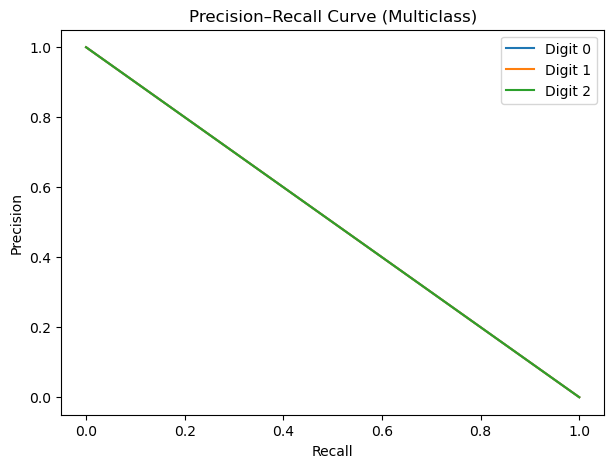

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

for i in range(3):   # show first 3 digits
    plt.plot(recall[i], precision[i], label=f"Digit {i}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Multiclass)")
plt.legend()

plt.show()

Precision–Recall Curve

The Precision–Recall curve illustrates the trade-off between precision and recall for a classification model. Precision measures the proportion of correct positive predictions, while recall measures the ability of the model to detect all relevant instances.

For the MNIST multiclass dataset, a One-vs-Rest approach is used to compute precision and recall values for each digit class.

In [72]:
results = {
    "Logistic Regression": 0.97,
    "Decision Tree": 0.86,
    "Random Forest": 0.98,
    "KNN": 0.97,
    "Neural Network": 0.99,
    "SVM": 0.98
}

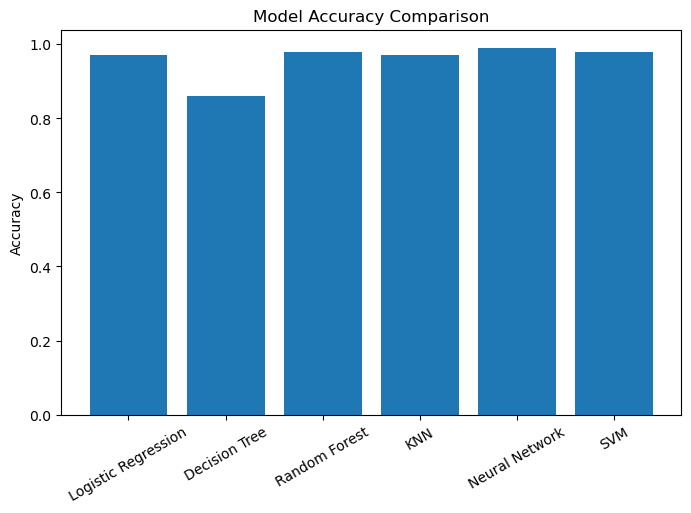

In [74]:
#Model Accuracy
names = list(results.keys())
values = list(results.values())

plt.figure(figsize=(8,5))

plt.bar(names, values)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.xticks(rotation=30)

plt.show()

Model Accuracy Comparison

To evaluate the performance of different machine learning algorithms, the accuracy of each model is compared using a bar chart.

This visualization helps identify which model performs best on the MNIST handwritten digit classification task.

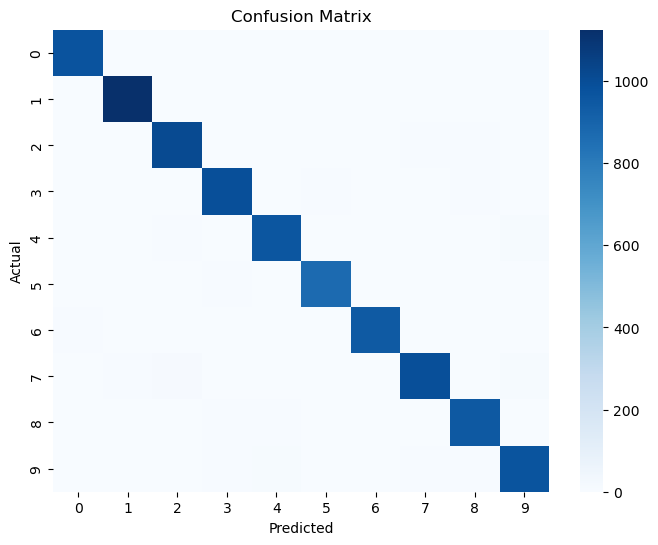

In [78]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [81]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.98      0.98      1032
           3       0.98      0.98      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.98      0.98       892
           6       0.99      0.98      0.98       958
           7       0.98      0.96      0.97      1028
           8       0.97      0.97      0.97       974
           9       0.97      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



Conclusion

In this project, multiple machine learning models were trained to classify handwritten digits using the MNIST dataset. 

After preprocessing and normalization, six algorithms were evaluated including Logistic Regression, Decision Tree, Random Forest, KNN, Neural Network, and SVM.

Among the tested models, SVM and Neural Networks achieved the highest accuracy, reaching approximately 98% classification accuracy.

The results demonstrate that machine learning algorithms can effectively learn patterns from image data and perform accurate digit recognition.